<a href="https://colab.research.google.com/github/Raimbek-pro/ml-projects/blob/main/rnnRO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

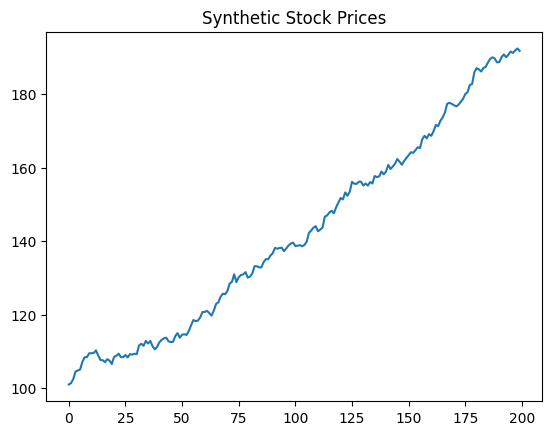

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic stock prices
np.random.seed(42)
days = 200
prices = np.cumsum(np.random.randn(days) + 0.5) + 100  # random walk starting around 100

plt.plot(prices)
plt.title("Synthetic Stock Prices")
plt.show()

In [ ]:
def create_sequences(data, seq_length):
    xs = []
    ys = []
    for i in range(len(data) - seq_length):
        x = data[i:i+seq_length]
        y = data[i+seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

seq_length = 30
X, Y = create_sequences(prices, seq_length)

print(X.shape, Y.shape)  # Check shapes

(170, 30) (170,)


In [ ]:
import torch
mean = np.mean(prices)
std = np.std(prices)
prices_norm = (prices - mean) / std

# Re-create sequences
X, Y = create_sequences(prices_norm, seq_length)
X_tensor = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)
Y_tensor = torch.tensor(Y, dtype=torch.float32).unsqueeze(-1)


In [ ]:
import torch.nn as nn

class StockRNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=1, output_size=1):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :])  # take the last time step
        return out

model = StockRNN()

In [ ]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

epochs = 100
for epoch in range(epochs):
    output = model(X_tensor)
    loss = criterion(output, Y_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 10, Loss: 0.0209
Epoch 20, Loss: 0.0156
Epoch 30, Loss: 0.0024
Epoch 40, Loss: 0.0028
Epoch 50, Loss: 0.0020
Epoch 60, Loss: 0.0018
Epoch 70, Loss: 0.0018
Epoch 80, Loss: 0.0016
Epoch 90, Loss: 0.0016
Epoch 100, Loss: 0.0016


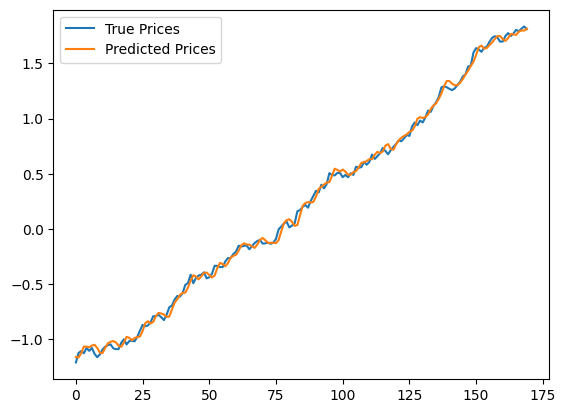

In [ ]:
with torch.no_grad():
    predictions = model(X_tensor).numpy()

plt.plot(Y, label="True Prices")
plt.plot(predictions, label="Predicted Prices")
plt.legend()
plt.show()

1. What’s the main difference between RNNs and feedforward neural networks?

Feedforward nets are acyclic: input → layers → output. They treat each example independently and have no memory of previous inputs.
RNNs have recurrence (loops): they pass a hidden state forward in time, so the network’s output at time t can depend on previous inputs. In practice that means parameter sharing across time and the ability to handle variable-length sequences.

2. Why do RNNs have a hidden state?

The hidden state is the RNN’s memory — it stores a summary of everything seen so far. At each timestep the RNN updates that hidden state with the new input, so information can flow across time steps (short-term memory). Mathematically:
h_t = f(W_{xh}x_t + W_{hh}h_{t-1} + b)
where h_t is the hidden state at time t. Without h_t the model would have no way to carry past context forward.

3. What kind of problems are RNNs typically used for?

Anything sequential or time-dependent:
	•	Natural language tasks (language modeling, text generation, translation, tagging)
	•	Speech recognition and synthesis
	•	Time-series forecasting (stock prices, sensor data)
	•	Sequence labeling (POS tagging, NER)
	•	Music, handwriting generation, video frame sequence tasks
(Modern models often use Transformers now, but RNNs were the go-to for sequential problems.)

4. What is the main drawback of vanilla RNNs?

The big pain: vanishing and exploding gradients during backpropagation through time (BPTT). That makes learning long-range dependencies (far-apart signals in the sequence) hard. Other practical drawbacks: they’re sequential to compute (limited parallelism → slower) and can be unstable to train. LSTM and GRU architectures were invented to mitigate the long-range memory problem.

5. How does the RNN process sequences step by step?

Short answer: it unrolls through time and updates hidden state each step. Concrete form and pseudocode:

Equations:
h_t = \tanh(W_{xh}x_t + W_{hh}h_{t-1} + b_h)\\
y_t = g(W_{hy}h_t + b_y)